# FairFace accuracy report

Reads `outputs/race_ground_truth/ground_truth_scores.csv` (produced by
`scripts/score_fairface_on_ground_truth.py`) plus the saved images to show:
1. A sample grid of faces per race (3x3), so you can eyeball what FairFace is actually looking at.
2. A bar chart of FairFace's race-classification accuracy per race category, with correct/incorrect counts.

Rerun this after `job_race_ground_truth_more` (job 3745466) finishes for the larger (60-seed) sample.

In [ ]:
import os
import random

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

DATA_DIR = "../data/ground_truth"
CSV_PATH = os.path.join(DATA_DIR, "ground_truth_scores.csv")

RACE_LABELS = [
    "White", "Black", "Latino_Hispanic", "East Asian",
    "Southeast Asian", "Indian", "Middle Eastern",
]

# dataviz reference palette, categorical slots 1-7
RACE_COLORS = {
    "White": "#2a78d6",
    "Black": "#008300",
    "Latino_Hispanic": "#e87ba4",
    "East Asian": "#eda100",
    "Southeast Asian": "#1baf7a",
    "Indian": "#eb6834",
    "Middle Eastern": "#4a3aa7",
}
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
CORRECT_COLOR = "#008300"
INCORRECT_COLOR = "#c0392b"

df = pd.read_csv(CSV_PATH)
df = df[df["pred_race"].notna() & (df["pred_race"] != "")]
print(f"{len(df)} scored faces across {df['true_race'].nunique()} race categories")
df.head()

## Sample grid: 9 faces per race
One figure per race category, 3x3 grid, randomly sampled from that category's generated images. Titles show FairFace's prediction (green = correct, red = wrong).

In [ ]:
random.seed(0)

def resolve_img_path(csv_path):
    # CSV stores paths relative to the old outputs/race_ground_truth location;
    # rewrite to the current DATA_DIR (now FairFace/data/ground_truth).
    rel = csv_path.split("race_ground_truth/", 1)[-1]
    return os.path.join(DATA_DIR, rel)

def plot_sample_grid(race, n=9, seed=0):
    race_rows = df[df["true_race"] == race]
    if race_rows.empty:
        print(f"no rows for {race}")
        return
    sample = race_rows.sample(n=min(n, len(race_rows)), random_state=seed)
    ncols = 3
    nrows = (len(sample) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3.4 * nrows), facecolor=SURFACE)
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_path = resolve_img_path(row["path"])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis("off")
        correct = row["pred_race"] == race
        color = CORRECT_COLOR if correct else INCORRECT_COLOR
        ax.set_title(f"pred: {row['pred_race']}", color=color, fontsize=9)
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle(f"{race} (n={len(race_rows)} total)", color=INK_PRIMARY, fontsize=13)
    fig.patch.set_facecolor(SURFACE)
    fig.tight_layout()
    plt.show()

for race in RACE_LABELS:
    plot_sample_grid(race)

## Per-race accuracy

In [3]:
acc_by_race = df.groupby("true_race")["race_correct"].agg(["mean", "count"]).reindex(RACE_LABELS)
acc_by_race.columns = ["accuracy", "n"]
acc_by_race

,accuracy,n
true_race,,
White,0.976744,43
Black,0.985075,67
Latino_Hispanic,0.510204,98
East Asian,0.990741,108
Southeast Asian,1.0,117
Indian,1.0,119
Middle Eastern,0.890756,119


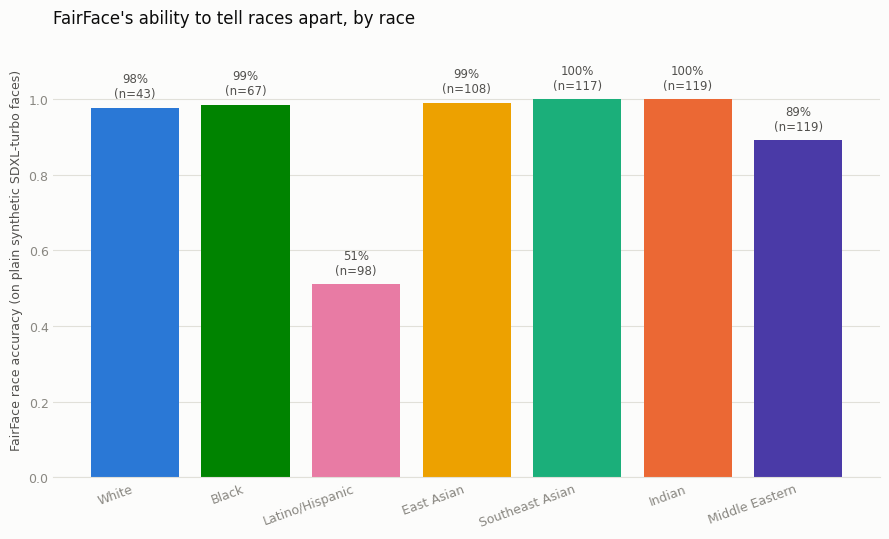

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=SURFACE)
x = range(len(RACE_LABELS))
bars = ax.bar(
    x,
    acc_by_race["accuracy"].to_numpy(),
    color=[RACE_COLORS[r] for r in RACE_LABELS],
    zorder=2,
)
for i, (bar, n) in enumerate(zip(bars, acc_by_race["n"])):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.02,
        f"{height:.0%}\n(n={n})", ha="center", va="bottom",
        color=INK_SECONDARY, fontsize=8.5,
    )

ax.set_facecolor(SURFACE)
fig.patch.set_facecolor(SURFACE)
ax.set_xticks(list(x))
ax.set_xticklabels([r.replace("_", "/") for r in RACE_LABELS], color=INK_MUTED, fontsize=9, rotation=20, ha="right")
ax.set_ylabel("FairFace race accuracy (on plain synthetic SDXL-turbo faces)", color=INK_SECONDARY, fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("FairFace's ability to tell races apart, by race", color=INK_PRIMARY, fontsize=12, pad=14, loc="left")
ax.tick_params(axis="both", colors=INK_MUTED, labelsize=9, length=0)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRIDLINE)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()

out_path = os.path.join(DATA_DIR, "plots")
os.makedirs(out_path, exist_ok=True)
fig.savefig(os.path.join(out_path, "fairface_accuracy_by_race.png"), dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Confusion matrix (heatmap)
Where FairFace's mistakes actually go -- e.g. Latino/Hispanic getting misread as Indian/Middle Eastern.

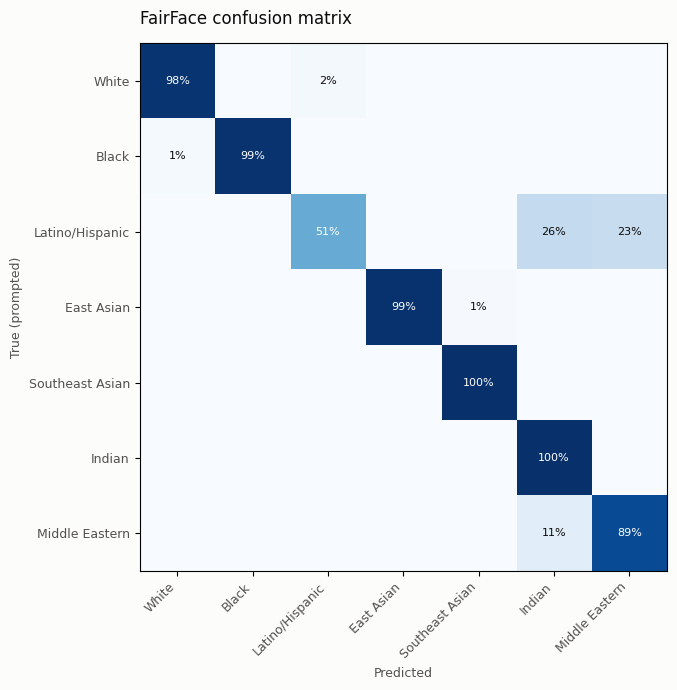

In [5]:
confusion = pd.crosstab(df["true_race"], df["pred_race"], normalize="index").reindex(index=RACE_LABELS, columns=RACE_LABELS, fill_value=0.0)

fig, ax = plt.subplots(figsize=(8, 7), facecolor=SURFACE)
im = ax.imshow(confusion.to_numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(RACE_LABELS)))
ax.set_yticks(range(len(RACE_LABELS)))
ax.set_xticklabels([r.replace("_", "/") for r in RACE_LABELS], rotation=45, ha="right", color=INK_SECONDARY, fontsize=9)
ax.set_yticklabels([r.replace("_", "/") for r in RACE_LABELS], color=INK_SECONDARY, fontsize=9)
ax.set_xlabel("Predicted", color=INK_SECONDARY, fontsize=9)
ax.set_ylabel("True (prompted)", color=INK_SECONDARY, fontsize=9)
ax.set_title("FairFace confusion matrix", color=INK_PRIMARY, fontsize=12, pad=14, loc="left")
for i in range(len(RACE_LABELS)):
    for j in range(len(RACE_LABELS)):
        v = confusion.to_numpy()[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", color="white" if v > 0.5 else INK_PRIMARY, fontsize=8)
fig.patch.set_facecolor(SURFACE)
fig.tight_layout()
fig.savefig(os.path.join(out_path, "fairface_confusion_matrix.png"), dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()